In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# | tags: [parameters]
subject_id = "170"

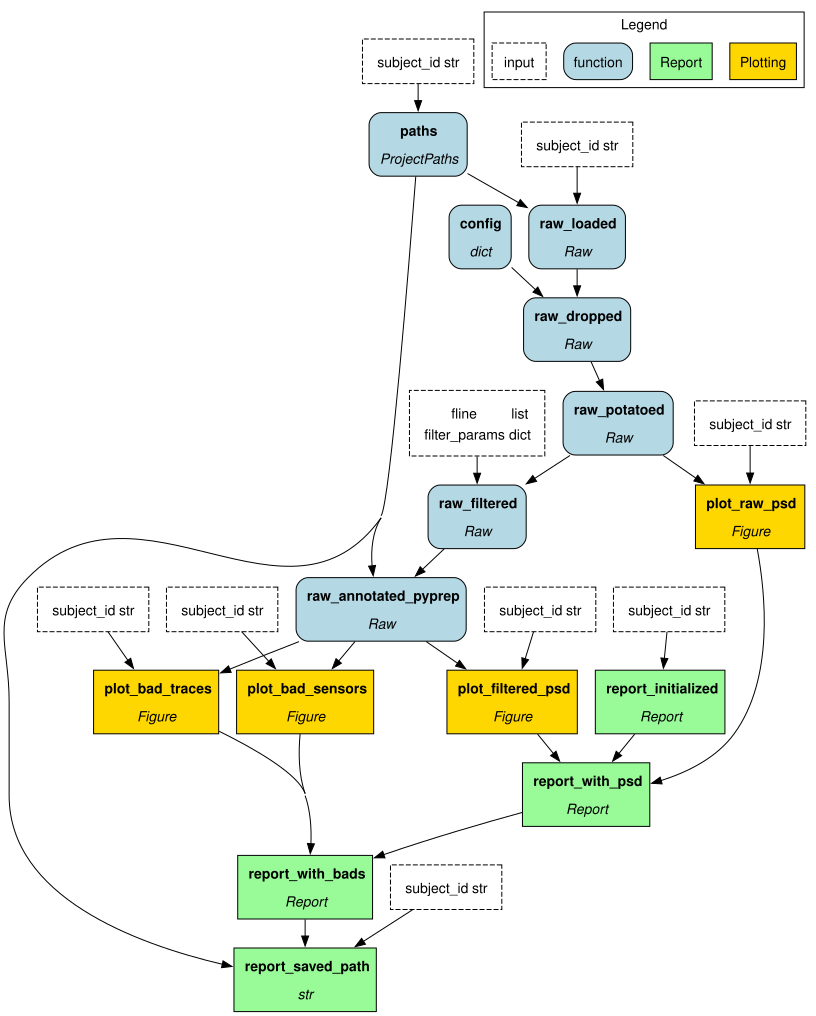

In [4]:
from IPython.display import display
from hamilton import telemetry

telemetry.disable_telemetry()

from hamilton import driver
from spectral.flows  import preprocessing
from spectral.helpers import style_cfg


filter_params = {
    "l_freq": 1.0,
    "h_freq": 45.0,
    "h_trans_bandwidth": "auto",
    "fir_window": "hamming",
    "fir_design": "firwin",
    "phase": "zero",
    "picks": ["ecg", "eeg"],
}

inputs = {"subject_id": subject_id , "fline": [50, 100], "filter_params": filter_params}

# Initialize Driver
dr = driver.Driver({}, preprocessing)

#  Display
dr.display_all_functions(orient="TB", custom_style_function=style_cfg)

In [ ]:
results = dr.execute(
    final_vars=[
        "raw_potatoed",
        "plot_raw_psd",
        "report_with_psd",
        "raw_filtered",
        "raw_annotated_pyprep",
        "plot_filtered_psd",
        "report_saved_path",
    ],
    inputs=inputs,
)



Created directories for sub-170
Project root: /Users/daniel/PhD/Projects/psd-paths
Loading BrainVision data from: sub-170_ses-01_task-RESTING_eeg.vhdr
Extracting parameters from /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-170/ses-01/eeg/sub-170_ses-01_task-RESTING_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 314879  =      0.000 ...   314.879 secs...
Loaded 258 channels, 314.9 seconds of data
Identified ECG channels: ['ECG']
Removed 'VREF' channel.
Applying GSN-HydroCel-256 montage...
   High-pass filtering > 0.5 Hz...
Trying Potato with threshold=2.9...
Potato fit successfully with threshold=2.9
Found 1 bad segments.
✅ Added 1 'BAD_potato' annotations to the raw object.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
Polyphase resampling neighborhood: ±2 input samples
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop

2025-12-18 01:30:57,562 - spectral.annotation - INFO - Running PyPREP on 204 channels at 125.0Hz.


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 413 samples (3.304 s)

Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 201
Total # of chunks: 1
Current chunk:
1

RANSAC done!
Found 12 uniquely bad channels:

0 by NaN: []

0 by flat: []

0 by deviation: []

0 by HF noise: []

3 by correlation: ['E53', 'E62', 'E202']

0 by SNR: []

0 by dropout: []

9 by RANSAC: [np.str_('E17'), np.str_('E54'), np.str_('E57'), np.str_('E63'), np.str_('E69'), np.str_('E132'), np.str_('E184'), np.str_('E185'), np.str_('E193')]

0 by manual: []



2025-12-18 01:31:06,400 - spectral.annotation - INFO - PyPREP identified 12 unique bad channels.
2025-12-18 01:31:06,404 - spectral.annotation - INFO - Raw object updated. Total bad channels: 12


Writing /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed/sub-170_annotated_filtered_raw.fif
Closing /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed/sub-170_annotated_filtered_raw.fif
[done]
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.
Overwriting existing file.
Saving report to : /Users/daniel/PhD/Projects/psd-paths/outputs/reports/sub-170/sub-170_report.h5
Overwriting existing file.
Saving report to : /Users/daniel/PhD/Projects/psd-paths/outputs/reports/sub-170/sub-170_report.html


2025-12-18 01:31:08,697 - hamilton.base - WARNING - It appears no Pandas index type was detected (ignore this warning if you're using DASK for now.) Please check whether the dataframe created matches what what you expect to happen.


# Plots

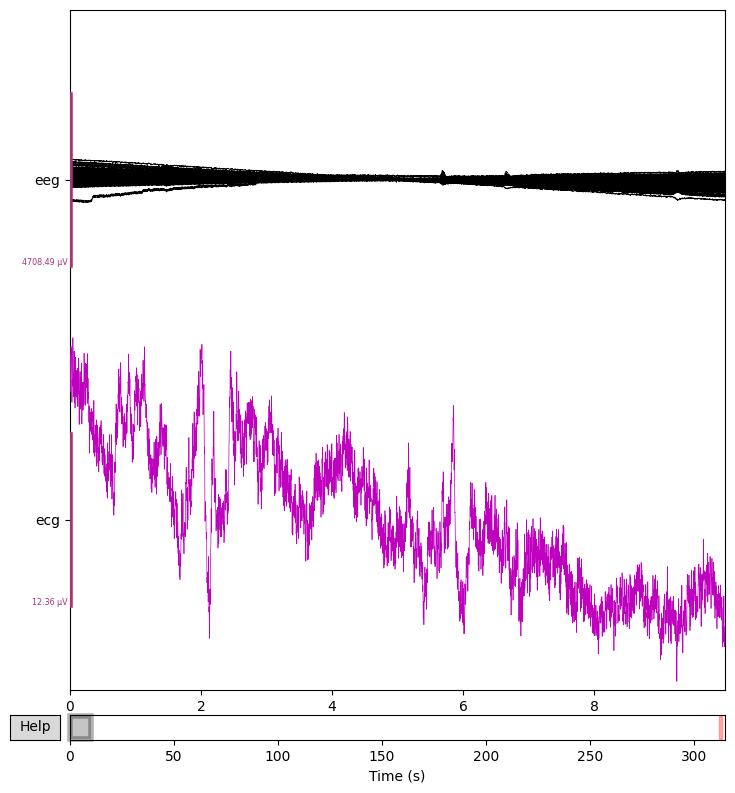

In [6]:
fig = results["raw_potatoed"].iloc[0].plot(scalings='auto', show=True,  butterfly=True)

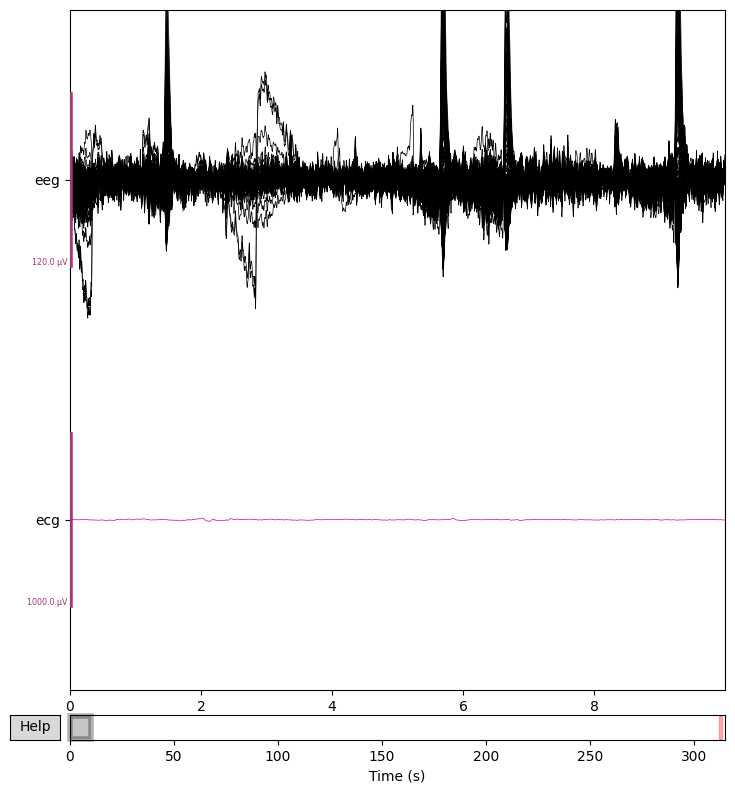

In [7]:
standard_scalings = {
    "eeg": 60e-6,  # 40 µV (Good for clean brainwaves)
    "ecg": 500e-6,  # 500 µV (ECG is naturally much larger)
    "eog": 150e-6,
}
fig = results["raw_filtered"].iloc[0].plot(scalings=standard_scalings, show=True,  butterfly=True)

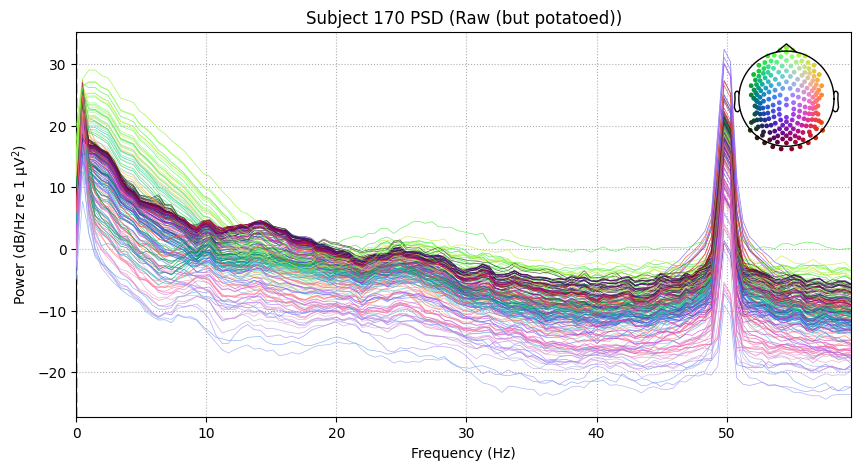

In [8]:

display(results["plot_raw_psd"].iloc[0] )

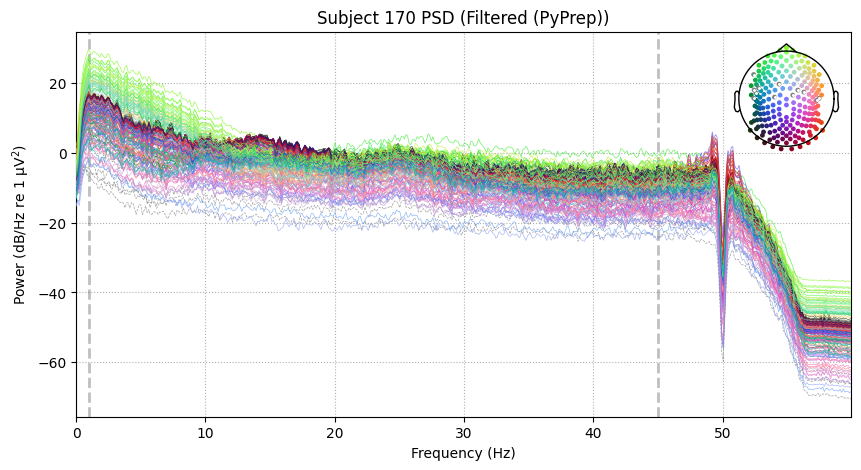

In [9]:
display(results["plot_filtered_psd"].iloc[0] )

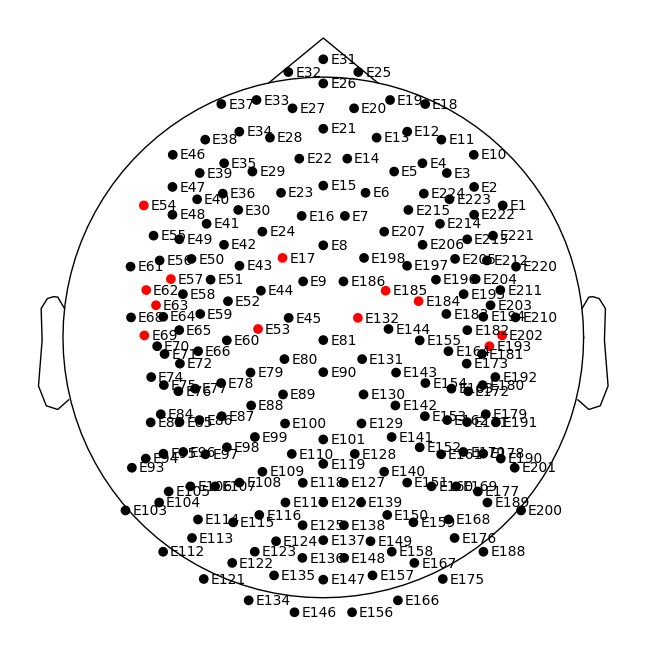

In [10]:
sensor_plot = results["raw_annotated_pyprep"].iloc[0].plot_sensors(show_names=True)
